In [45]:
import importlib
import facial_measurement_functions

importlib.reload(facial_measurement_functions)



I0000 00:00:1786547053.714832 2832823 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 83), renderer: Apple M2
W0000 00:00:1786547053.764909 2832823 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.


<module 'facial_measurement_functions' from '/Users/evedurant/Desktop/facemetric-api/models/facial_measurement_functions.py'>

In [ ]:
from facial_measurement_functions import get_detection_result_takes_path

from facial_measurement_functions import run_mediapipe_extract_symmetry_points

from facial_measurement_functions import get_angle_of_rotation

from facial_measurement_functions import rotate_landmarks

from facial_measurement_functions import canthal_tilt

from facial_measurement_functions import top_bottom_lip_ratio

from facial_measurement_functions import bottom_two_thirds

from facial_measurement_functions import nose_to_chin

from facial_measurement_functions import arch_symmetry

In [102]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/eve_below.jpg"
face = rotate_landmarks(img_path)
print(face)

[NormalizedLandmark(x=0.5042438299920492, y=0.5103784471512024, z=-0.10352356731891632, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.5030499280734313, y=0.45218698975692895, z=-0.14034244418144226, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.503612672256645, y=0.4777892972774388, z=-0.08612881600856781, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.4801257294359661, y=0.40941083819684115, z=-0.08597368746995926, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.5026583296435638, y=0.43631037421510516, z=-0.1437513679265976, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.5025720717670672, y=0.4194812101274619, z=-0.12572915852069855, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.5037863823550389, y=0.38091916418529376, z=-0.03176657482981682, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.3183101939234868, y=0.3878338918054355, z=0.0680975690484047, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.5036036754479043, y=0.3345102283

## Face Landmark Visualisation

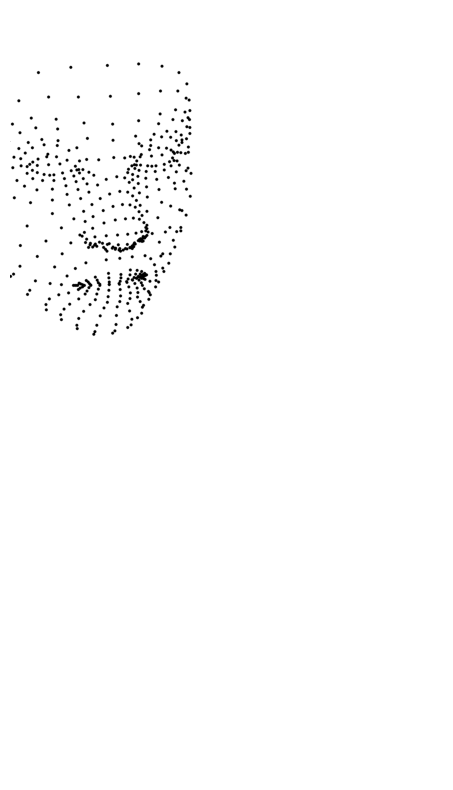

In [93]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt


def draw_landmarks_on_blank(face, width, height):
    """
    Draw MediaPipe landmarks on a blank white image.

    face:
        detection_result.face_landmarks[0]

    width, height:
        dimensions of the original image
    """

    # Create a white RGB image
    blank_img = np.ones(
        (height, width, 3),
        dtype=np.uint8
    ) * 255

    for landmark in face:

        # Normalized coordinates -> pixel coordinates
        x = int(landmark.x * width)
        y = int(landmark.y * height)

        cv.circle(
            blank_img,
            (x, y),
            radius=4,
            color=(0, 0, 0),
            thickness=-1,
        )

    return blank_img

img = cv.imread(img_path)

h, w = img.shape[:2]



blank_landmarks = draw_landmarks_on_blank(
    face,
    width=w,
    height=h,
)

plt.figure(figsize=(8, 10))
plt.imshow(blank_landmarks)
plt.axis("off")
plt.show()

### Canthal Tilt 

In [94]:
theta_left, theta_right = canthal_tilt(face)
print(f" the canthal tilt of the left eye is {theta_left} and the right is {theta_right}. The ideal is 4 to 8 degrees and the eyes should have the same tilt")

 the canthal tilt of the left eye is 1.8843325699905613 and the right is 9.18144809944469. The ideal is 4 to 8 degrees and the eyes should have the same tilt


### Bottom to top lip ratio

In [95]:
lip_ratio = top_bottom_lip_ratio(face)
print(f" the bottom lip is {lip_ratio} times as large as the top lip. The ideal is 1.6 ")

 the bottom lip is 1.9499981844751102 times as large as the top lip. The ideal is 1.6 


### Bottom two thrids ratio

In [96]:
bottom_thirds_ratio = bottom_two_thirds(face)
print(f" the middle third is {bottom_thirds_ratio} times as large as the bottom third. The ideal is roughly {1/0.9}. You deviate by.... ")

 the middle third is 1.351624290059207 times as large as the bottom third. The ideal is roughly 1.1111111111111112. You deviate by.... 


### Nose to bottom of lips to chin

In [97]:
nose_to_chin_ratio = nose_to_chin(face)
print(f" the ratio between the nose to the bottom of the lips and the bottom of the lips to the chin is {nose_to_chin_ratio}. It should be 1")

 the ratio between the nose to the bottom of the lips and the bottom of the lips to the chin is 1.6165229832471582. It should be 1


### Arch Symmetry

In [98]:
left, right = arch_symmetry(face)
print(f"the horizontal distance form the centre to the left brow arch is {left} and to the right brow arch is {right}")
    

right arch : 0.04900127895365117
the horizontal distance form the centre to the left brow arch is 0.14481034647498586 and to the right brow arch is 0.18803227088623967


## Investigating Yaw, Pitch and Roll

This is the amount that the head is tilted in the x y and z directions. I am thinking that for now i will determine these angles and reject the photo if the yaw (looking left/right) or pitch (looking up/down) deviate too much. Later I will build in a rotation matrix that can correct this and perform a symmetry analysis.



![rotation matrix](/Users/evedurant/Desktop/facemetric-api/tests/rotation_matrix.jpg)

In [99]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/eve_above.jpg"

detection_result = get_detection_result_takes_path(img_path)

matrix = detection_result.facial_transformation_matrixes[0]
print(f"matrix: {matrix}")
print(f"matrix shape: {matrix.shape}")

matrix: [[ 9.66628432e-01  1.27836868e-01  2.22008198e-01 -1.24461174e-01]
 [-3.38615812e-02  9.22751784e-01 -3.83905351e-01  5.64438915e+00]
 [-2.53935575e-01  3.63576084e-01  8.96286845e-01 -4.28796997e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
matrix shape: (4, 4)


In [100]:
def convert_rotate_matrix_to_euler(M):
    """
    converts a 4 by 4 rotation matrix
    into pitch, yaw and roll, returning 
    angles in degrees.
    """

    # M00 = cos(z)cos(y),  M10 = sin(z)sin(y)
    # and so abs_cosy = |cos(y)|
    abs_cosy = np.sqrt(M[0, 0]**2+M[1, 0]**2)

    # cos(0) = 90 which would mean a full rotation,
    #  this is a problematic case
    head_turned = abs_cosy < 1e-5

    if not head_turned:

        # This calculates the rotation angle around what 
        # we are calling the x axis

        # since M21 = cos(y)sin(x) and M22 = cos(y)cos(x),
        # arctan(sinx/cos(x)) will give x

        # same logic applies to getting angles y and z
        x = np.arctan2(M[2, 1], M[2, 2])

        #M20 = -sin(y) and so manipulating this gives y
        y = np.arctan2(-M[2, 0], abs_cosy)
        z = np.arctan2(M[1, 0], M[0, 0])

    else:

        # M 
        x = np.arctan2(-M[1, 2], M[1, 1])
        y = np.arctan2(-M[2, 0], abs_cosy)
        z = 0

    euler_angles_derees = np.degrees([x, y, z])
    return euler_angles_derees

    

In [106]:
pitch, yaw, roll = convert_rotate_matrix_to_euler(matrix)
print("Pitch (looking up/down - from below gives negative angle):", pitch)
print("Yaw (looking left/right):", yaw)
print("Roll (head towards shoulder):", roll)

Pitch (looking up/down - from below gives negative angle): -10.974159611465698
Yaw (looking left/right): -0.15926199026525253
Roll (head towards shoulder): -0.6680418405361411


### Visualise and Test Pitch, Yaw and Roll results




## Test 1

<div>
<img src="/Users/evedurant/Desktop/facemetric-api/tests/face.jpg" width = 200/>
</div>

In [103]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/face.jpg"

detection_result = get_detection_result_takes_path(img_path)

matrix = detection_result.facial_transformation_matrixes[0]

pitch, yaw, roll = convert_rotate_matrix_to_euler(matrix)
print("Pitch (looking up/down):", pitch)
print("Yaw (looking left/right):", yaw)
print("Roll (head towards shoulder):", roll)

Pitch (looking up/down): 9.137628121384305
Yaw (looking left/right): 2.1030290580991444
Roll (head towards shoulder): -0.4481877420052801


/Users/evedurant/Desktop/facemetric-api/.venv/lib/python3.9/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


## Test 2

<div>
<img src="/Users/evedurant/Desktop/facemetric-api/tests/test_images/eve_above.jpg" width = 200/>
</div>

In [107]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/test_images/eve_above.jpg"

detection_result = get_detection_result_takes_path(img_path)

matrix = detection_result.facial_transformation_matrixes[0]

pitch, yaw, roll = convert_rotate_matrix_to_euler(matrix)
print("Pitch (looking up/down - below angle gives negative result):", pitch)
print("Yaw (looking left/right - looking right is positive):", yaw)
print("Roll (head towards shoulder):", roll)

Pitch (looking up/down - below angle gives negative result): 22.079787799918805
Yaw (looking left/right - looking right is positive): 14.710519081926689
Roll (head towards shoulder): -2.0062855667589172


## Test 3

<div>
<img src="/Users/evedurant/Desktop/facemetric-api/tests/test_images/eve_below.jpg" width = 200/>
</div>

In [108]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/test_images/eve_below.jpg"

detection_result = get_detection_result_takes_path(img_path)

matrix = detection_result.facial_transformation_matrixes[0]

pitch, yaw, roll = convert_rotate_matrix_to_euler(matrix)
print("Pitch (looking up/down):", pitch)
print("Yaw (looking left/right):", yaw)
print("Roll (head towards shoulder):", roll)

Pitch (looking up/down): -10.974159611465698
Yaw (looking left/right): -0.15926199026525253
Roll (head towards shoulder): -0.6680418405361411


## Test 4

<div>
<img src="/Users/evedurant/Desktop/facemetric-api/tests/test_images/eve_head_tilt.jpg" width = 200/>
</div>

In [ ]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/test_images/eve_head_tilt.jpg"

detection_result = get_detection_result_takes_path(img_path)

matrix = detection_result.facial_transformation_matrixes[0]

pitch, yaw, roll = convert_rotate_matrix_to_euler(matrix)
print("Pitch (looking up/down):", pitch)
print("Yaw (looking left/right):", yaw)
print("Roll (head towards shoulder) - tilted right is negative:", roll)

Pitch (looking up/down): 6.280542704277888
Yaw (looking left/right): 6.257175789490263
Roll (head towards shoulder): -30.68663688044011


## Test 5

<div>
<img src="/Users/evedurant/Desktop/facemetric-api/tests/test_images/above.jpg" width = 200/>
</div>

In [110]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/test_images/above.jpg"

detection_result = get_detection_result_takes_path(img_path)

matrix = detection_result.facial_transformation_matrixes[0]

pitch, yaw, roll = convert_rotate_matrix_to_euler(matrix)
print("Pitch (looking up/down):", pitch)
print("Yaw (looking left/right):", yaw)
print("Roll (head towards shoulder) - tilted right is negative:", roll)

Pitch (looking up/down): 35.84925915518215
Yaw (looking left/right): 1.792936152154671
Roll (head towards shoulder) - tilted right is negative: -1.8506123185018786


## Test 6

<div>
<img src="/Users/evedurant/Desktop/facemetric-api/tests/test_images/deeba.jpg" width = 200/>
</div>

In [111]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/test_images/deeba.jpg"

detection_result = get_detection_result_takes_path(img_path)

matrix = detection_result.facial_transformation_matrixes[0]

pitch, yaw, roll = convert_rotate_matrix_to_euler(matrix)
print("Pitch (looking up/down):", pitch)
print("Yaw (looking left/right):", yaw)
print("Roll (head towards shoulder) - tilted right is negative:", roll)

Pitch (looking up/down): 1.6839157601358017
Yaw (looking left/right): -0.2988621778993943
Roll (head towards shoulder) - tilted right is negative: -0.5778787130473911


## Test 7

<div>
<img src="/Users/evedurant/Desktop/facemetric-api/tests/test_images/0A43E76F5A0F9EA499B7440E66080CC1D67C15970C05C220F26047C72155B5BE_sk_45_cid_1.jpeg" width = 200/>
</div>

In [112]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/test_images/0A43E76F5A0F9EA499B7440E66080CC1D67C15970C05C220F26047C72155B5BE_sk_45_cid_1.jpeg"

detection_result = get_detection_result_takes_path(img_path)

matrix = detection_result.facial_transformation_matrixes[0]

pitch, yaw, roll = convert_rotate_matrix_to_euler(matrix)
print("Pitch (looking up/down):", pitch)
print("Yaw (looking left/right):", yaw)
print("Roll (head towards shoulder) - tilted right is negative:", roll)

Pitch (looking up/down): 0.4531612397150012
Yaw (looking left/right): -22.12010034204253
Roll (head towards shoulder) - tilted right is negative: 2.7672741319158325


/Users/evedurant/Desktop/facemetric-api/.venv/lib/python3.9/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


## Test 8

<div>
<img src="/Users/evedurant/Desktop/facemetric-api/tests/test_images/0A506DCC614F650AA9E4AD402F739DF6FBBF686672EAF9C4BA8AFC8A8DAB5A15_sk_45_cid_1.jpeg" width = 200/>
</div>

In [113]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/test_images/0A506DCC614F650AA9E4AD402F739DF6FBBF686672EAF9C4BA8AFC8A8DAB5A15_sk_45_cid_1.jpeg"

detection_result = get_detection_result_takes_path(img_path)

matrix = detection_result.facial_transformation_matrixes[0]

pitch, yaw, roll = convert_rotate_matrix_to_euler(matrix)
print("Pitch (looking up/down):", pitch)
print("Yaw (looking left/right):", yaw)
print("Roll (head towards shoulder) - tilted right is negative:", roll)

Pitch (looking up/down): 7.4586621355451035
Yaw (looking left/right): -0.8895757442121426
Roll (head towards shoulder) - tilted right is negative: 1.341162724467202


## Test 9

<div>
<img src="/Users/evedurant/Desktop/facemetric-api/tests/test_images/0b7bd790-9e84-4de9-8324-3ad6a2e6d498.jpg" width = 200/>
</div>

In [114]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/test_images/0b7bd790-9e84-4de9-8324-3ad6a2e6d498.jpg"

detection_result = get_detection_result_takes_path(img_path)

matrix = detection_result.facial_transformation_matrixes[0]

pitch, yaw, roll = convert_rotate_matrix_to_euler(matrix)
print("Pitch (looking up/down):", pitch)
print("Yaw (looking left/right):", yaw)
print("Roll (head towards shoulder) - tilted right is negative:", roll)

Pitch (looking up/down): -3.2917244068468583
Yaw (looking left/right): -13.491316039812212
Roll (head towards shoulder) - tilted right is negative: 9.469170402038408


## Test 10

<div>
<img src="/Users/evedurant/Desktop/facemetric-api/tests/test_images/6A9697E7E111F6C67046656FFEFAFBE191C5F82AA7518490078C4C31702E71E4_sk_12_cid_1.jpeg" width = 200/>
</div>

In [115]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/test_images/6A9697E7E111F6C67046656FFEFAFBE191C5F82AA7518490078C4C31702E71E4_sk_12_cid_1.jpeg"

detection_result = get_detection_result_takes_path(img_path)

matrix = detection_result.facial_transformation_matrixes[0]

pitch, yaw, roll = convert_rotate_matrix_to_euler(matrix)
print("Pitch (looking up/down):", pitch)
print("Yaw (looking left/right):", yaw)
print("Roll (head towards shoulder) - tilted right is negative:", roll)

Pitch (looking up/down): 2.0223655718347926
Yaw (looking left/right): -8.6052733494162
Roll (head towards shoulder) - tilted right is negative: 0.7807184350482013


## Test 11

<div>
<img src="/Users/evedurant/Desktop/facemetric-api/tests/test_images/9BD3790A4FC9E2C9E9AE38C715C1BA829F9AB745D4E0E6809C41699767301626_sk_45_cid_1.jpeg" width = 200/>
</div>

In [118]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/test_images/9BD3790A4FC9E2C9E9AE38C715C1BA829F9AB745D4E0E6809C41699767301626_sk_45_cid_1.jpeg"

detection_result = get_detection_result_takes_path(img_path)

matrix = detection_result.facial_transformation_matrixes[0]

pitch, yaw, roll = convert_rotate_matrix_to_euler(matrix)
print("Pitch (looking up/down):", pitch)
print("Yaw (looking left/right) - right is positive:", yaw)
print("Roll (head towards shoulder) - tilted right is negative:", roll)

Pitch (looking up/down): -0.6718556605774447
Yaw (looking left/right) - right is positive: 6.020619820999083
Roll (head towards shoulder) - tilted right is negative: -14.35858067900938


## Test 12

<div>
<img src="/Users/evedurant/Desktop/facemetric-api/tests/test_images/9D02587E6F5035447B7ADF1B501C9AA9E8476827ADDE579C1E5824C0E1078877_sk_45_cid_1.jpeg" width = 200/>
</div>

In [119]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/test_images/9D02587E6F5035447B7ADF1B501C9AA9E8476827ADDE579C1E5824C0E1078877_sk_45_cid_1.jpeg"

detection_result = get_detection_result_takes_path(img_path)

matrix = detection_result.facial_transformation_matrixes[0]

pitch, yaw, roll = convert_rotate_matrix_to_euler(matrix)
print("Pitch (looking up/down):", pitch)
print("Yaw (looking left/right):", yaw)
print("Roll (head towards shoulder) - tilted right is negative:", roll)

Pitch (looking up/down): 8.387668020727041
Yaw (looking left/right): 21.566584635135786
Roll (head towards shoulder) - tilted right is negative: 9.275995482946998


## Test 13

<div>
<img src="/Users/evedurant/Desktop/facemetric-api/tests/test_images/15BA2F1F487D34369EFE26565EE6DEF612496276154C5BFDB0EC125E5E849E9D_sk_45_cid_1.jpeg" width = 200/>
</div>

In [122]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/test_images/15BA2F1F487D34369EFE26565EE6DEF612496276154C5BFDB0EC125E5E849E9D_sk_45_cid_1.jpeg"

detection_result = get_detection_result_takes_path(img_path)

matrix = detection_result.facial_transformation_matrixes[0]

pitch, yaw, roll = convert_rotate_matrix_to_euler(matrix)
print("Pitch (looking up/down):", pitch)
print("Yaw (looking left/right):", yaw)
print("Roll (head towards shoulder) - tilted right is negative:", roll)

Pitch (looking up/down): 2.6470743775936185
Yaw (looking left/right): 1.2252827146071696
Roll (head towards shoulder) - tilted right is negative: 0.9676926629635583


## Test 14

<div>
<img src="/Users/evedurant/Desktop/facemetric-api/tests/test_images/PHOTO-2026-08-16-16-58-27.jpg" width = 200/>
</div>

In [121]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/test_images/PHOTO-2026-08-16-16-58-27.jpg"

detection_result = get_detection_result_takes_path(img_path)

matrix = detection_result.facial_transformation_matrixes[0]

pitch, yaw, roll = convert_rotate_matrix_to_euler(matrix)
print("Pitch (looking up/down):", pitch)
print("Yaw (looking left/right):", yaw)
print("Roll (head towards shoulder) - tilted right is negative:", roll)

Pitch (looking up/down): 8.835222179330973
Yaw (looking left/right): -0.11155965056454066
Roll (head towards shoulder) - tilted right is negative: 0.1610965156976247


## Test 15

<div>
<img src="/Users/evedurant/Desktop/facemetric-api/tests/test_images/PHOTO-2026-08-16-17-08-45.jpg" width = 200/>
</div>

In [123]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/test_images/PHOTO-2026-08-16-17-08-45.jpg"

detection_result = get_detection_result_takes_path(img_path)

matrix = detection_result.facial_transformation_matrixes[0]

pitch, yaw, roll = convert_rotate_matrix_to_euler(matrix)
print("Pitch (looking up/down):", pitch)
print("Yaw (looking left/right):", yaw)
print("Roll (head towards shoulder) - tilted right is negative:", roll)

Pitch (looking up/down): 3.64605207075231
Yaw (looking left/right): -2.316789039111791
Roll (head towards shoulder) - tilted right is negative: 0.5779448336974331


## Now investigating if roll is roughly equal to my get_rotation_angle function

In [126]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/test_images/PHOTO-2026-08-16-17-08-45.jpg"
img = cv.imread(img_path)
detection_result = get_detection_result_takes_path(img_path)
x, y = run_mediapipe_extract_symmetry_points(detection_result, img)
theta, _ = get_angle_of_rotation(img, x, y)
theta = np.rad2deg(theta)
print(f"theta from my funciton is {theta}")
matrix = detection_result.facial_transformation_matrixes[0]

_, _, roll = convert_rotate_matrix_to_euler(matrix)

print("Roll (head towards shoulder) - tilted right is negative:", roll)

theta from my funciton is 1.5046088503742086
Roll (head towards shoulder) - tilted right is negative: 0.5779448336974331


/Users/evedurant/Desktop/facemetric-api/.venv/lib/python3.9/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


### Testing another image


In [127]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/test_images/ben.jpeg"
img = cv.imread(img_path)
detection_result = get_detection_result_takes_path(img_path)
x, y = run_mediapipe_extract_symmetry_points(detection_result, img)
theta, _ = get_angle_of_rotation(img, x, y)
theta = np.rad2deg(theta)
print(f"theta from my funciton is {theta}")
matrix = detection_result.facial_transformation_matrixes[0]

_, _, roll = convert_rotate_matrix_to_euler(matrix)

print("Roll (head towards shoulder) - tilted right is negative:", roll)

theta from my funciton is -2.4259964146989073
Roll (head towards shoulder) - tilted right is negative: -2.602971596492947


### and another

<div>
<img src="/Users/evedurant/Desktop/facemetric-api/tests/test_images/9BD3790A4FC9E2C9E9AE38C715C1BA829F9AB745D4E0E6809C41699767301626_sk_45_cid_1.jpeg" width = 200/>
</div>

In [128]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/test_images/9BD3790A4FC9E2C9E9AE38C715C1BA829F9AB745D4E0E6809C41699767301626_sk_45_cid_1.jpeg"
img = cv.imread(img_path)
detection_result = get_detection_result_takes_path(img_path)
x, y = run_mediapipe_extract_symmetry_points(detection_result, img)
theta, _ = get_angle_of_rotation(img, x, y)
theta = np.rad2deg(theta)
print(f"theta from my funciton is {theta}")
matrix = detection_result.facial_transformation_matrixes[0]

_, _, roll = convert_rotate_matrix_to_euler(matrix)

print("Roll (head towards shoulder) - tilted right is negative:", roll)

theta from my funciton is -15.255118703057775
Roll (head towards shoulder) - tilted right is negative: -14.35858067900938
